In [3]:
import pandas as pd
file_path="TRADES.csv"
df = pd.read_csv(file_path)
df.head()

,Port_IDs,Trade_History
0,3925368433214965504,"[{'time': 1718899656000, 'symbol': 'SOLUSDT', ..."
1,4002413037164645377,"[{'time': 1718980078000, 'symbol': 'NEARUSDT',..."
2,3923766029921022977,"[{'time': 1718677164000, 'symbol': 'ETHUSDT', ..."
3,3994879592543698688,"[{'time': 1718678214000, 'symbol': 'ETHUSDT', ..."
4,3926423286576838657,"[{'time': 1718979615000, 'symbol': 'ETHUSDT', ..."


In [4]:
df.dtypes

Port_IDs          int64
Trade_History    object
dtype: object

In [9]:
df.head()

,Port_IDs,Trade_History
0,3925368433214965504,"[{'time': 1718899656000, 'symbol': 'SOLUSDT', ..."
1,4002413037164645377,"[{'time': 1718980078000, 'symbol': 'NEARUSDT',..."
2,3923766029921022977,"[{'time': 1718677164000, 'symbol': 'ETHUSDT', ..."
3,3994879592543698688,"[{'time': 1718678214000, 'symbol': 'ETHUSDT', ..."
4,3926423286576838657,"[{'time': 1718979615000, 'symbol': 'ETHUSDT', ..."


In [6]:
df.isnull().sum()

Port_IDs         0
Trade_History    1
dtype: int64

In [10]:
df_cleaned = df.dropna()

df_cleaned.isnull().sum()


Port_IDs         0
Trade_History    0
dtype: int64

In [14]:
df_cleaned["Trade_History"].head(3)

0    [{'time': 1718899656000, 'symbol': 'SOLUSDT', ...
1    [{'time': 1718980078000, 'symbol': 'NEARUSDT',...
2    [{'time': 1718677164000, 'symbol': 'ETHUSDT', ...
Name: Trade_History, dtype: object

In [13]:
df_cleaned.columns

Index(['Port_IDs', 'Trade_History'], dtype='object')

In [15]:
import ast  
sample_trade = df_cleaned["Trade_History"].iloc[0]


if isinstance(sample_trade, str):
    sample_trade = ast.literal_eval(sample_trade) 
print(sample_trade)


[{'time': 1718899656000, 'symbol': 'SOLUSDT', 'side': 'BUY', 'price': 132.537, 'fee': -0.9940275, 'feeAsset': 'USDT', 'quantity': 1988.055, 'quantityAsset': 'USDT', 'realizedProfit': 0.0, 'realizedProfitAsset': 'USDT', 'baseAsset': 'SOL', 'qty': 15.0, 'positionSide': 'LONG', 'activeBuy': True}, {'time': 1718899618000, 'symbol': 'DOGEUSDT', 'side': 'BUY', 'price': 0.12182, 'fee': -0.27979617, 'feeAsset': 'USDT', 'quantity': 1398.98088, 'quantityAsset': 'USDT', 'realizedProfit': 0.0, 'realizedProfitAsset': 'USDT', 'baseAsset': 'DOGE', 'qty': 11484.0, 'positionSide': 'LONG', 'activeBuy': False}, {'time': 1718899618000, 'symbol': 'DOGEUSDT', 'side': 'BUY', 'price': 0.12182, 'fee': -0.03949404, 'feeAsset': 'USDT', 'quantity': 197.47022, 'quantityAsset': 'USDT', 'realizedProfit': 0.0, 'realizedProfitAsset': 'USDT', 'baseAsset': 'DOGE', 'qty': 1621.0, 'positionSide': 'LONG', 'activeBuy': False}, {'time': 1718899616000, 'symbol': 'DOGEUSDT', 'side': 'BUY', 'price': 0.12182, 'fee': -0.00828375,

In [19]:
# import json

# # Function to expand trade history
# def expand_trade_history(row):
#     trades = json.loads(row) if isinstance(row, str) else row  # Convert string to JSON
#     return pd.DataFrame(trades)  # Convert to DataFrame

# # Expand each Trade_History row into a separate DataFrame
# expanded_trades = df_cleaned["Trade_History"].apply(expand_trade_history)

# # Combine all expanded data into a single DataFrame
# df_trades = pd.concat(expanded_trades.tolist(), ignore_index=True)

# # Display the first few rows
# print(df_trades.head())


In [17]:
print(df_cleaned["Trade_History"].head(5).tolist())

["[{'time': 1718899656000, 'symbol': 'SOLUSDT', 'side': 'BUY', 'price': 132.537, 'fee': -0.9940275, 'feeAsset': 'USDT', 'quantity': 1988.055, 'quantityAsset': 'USDT', 'realizedProfit': 0.0, 'realizedProfitAsset': 'USDT', 'baseAsset': 'SOL', 'qty': 15.0, 'positionSide': 'LONG', 'activeBuy': True}, {'time': 1718899618000, 'symbol': 'DOGEUSDT', 'side': 'BUY', 'price': 0.12182, 'fee': -0.27979617, 'feeAsset': 'USDT', 'quantity': 1398.98088, 'quantityAsset': 'USDT', 'realizedProfit': 0.0, 'realizedProfitAsset': 'USDT', 'baseAsset': 'DOGE', 'qty': 11484.0, 'positionSide': 'LONG', 'activeBuy': False}, {'time': 1718899618000, 'symbol': 'DOGEUSDT', 'side': 'BUY', 'price': 0.12182, 'fee': -0.03949404, 'feeAsset': 'USDT', 'quantity': 197.47022, 'quantityAsset': 'USDT', 'realizedProfit': 0.0, 'realizedProfitAsset': 'USDT', 'baseAsset': 'DOGE', 'qty': 1621.0, 'positionSide': 'LONG', 'activeBuy': False}, {'time': 1718899616000, 'symbol': 'DOGEUSDT', 'side': 'BUY', 'price': 0.12182, 'fee': -0.0082837

In [18]:
import ast  # Safer than json.loads for malformed data

# Function to clean and convert Trade_History
def clean_trade_history(trade_str):
    try:
        # Fix malformed strings
        trade_str = trade_str.strip('"')  # Remove extra quotes
        trade_str = trade_str.replace("'", '"')  # Replace single quotes with double quotes
        
        # Convert string to list of dictionaries
        trade_list = ast.literal_eval(trade_str)  
        return trade_list  # Return the cleaned list
    except Exception as e:
        print("Error processing row:", e)
        return []  # Return an empty list if there's an issue

# Apply cleaning function to each row
df_cleaned["Trade_History"] = df_cleaned["Trade_History"].apply(clean_trade_history)

# Expand the cleaned trade history into a new DataFrame
df_trades = df_cleaned.explode("Trade_History")  # One row per trade

# Convert dictionary entries to separate columns
df_trades = pd.json_normalize(df_trades["Trade_History"])

# Display first few rows
print(df_trades.head())


C:\Users\DELL\AppData\Local\Temp\ipykernel_11684\1600180079.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned["Trade_History"] = df_cleaned["Trade_History"].apply(clean_trade_history)


            time    symbol side      price       fee feeAsset    quantity  \
0  1718899656000   SOLUSDT  BUY  132.53700 -0.994027     USDT  1988.05500   
1  1718899618000  DOGEUSDT  BUY    0.12182 -0.279796     USDT  1398.98088   
2  1718899618000  DOGEUSDT  BUY    0.12182 -0.039494     USDT   197.47022   
3  1718899616000  DOGEUSDT  BUY    0.12182 -0.008284     USDT    16.56752   
4  1718899616000  DOGEUSDT  BUY    0.12182 -0.046109     USDT    92.21774   

  quantityAsset  realizedProfit realizedProfitAsset baseAsset      qty  \
0          USDT             0.0                USDT       SOL     15.0   
1          USDT             0.0                USDT      DOGE  11484.0   
2          USDT             0.0                USDT      DOGE   1621.0   
3          USDT             0.0                USDT      DOGE    136.0   
4          USDT             0.0                USDT      DOGE    757.0   

  positionSide  activeBuy  
0         LONG       True  
1         LONG      False  
2       

In [40]:
# Group data by Port_ID
df_metrics = df_trades.groupby('Port_IDs').agg(
    Total_PnL=('realizedProfit', 'sum'),  # Total Profit & Loss
    Win_Positions=('realizedProfit', lambda x: (x > 0).sum()),  # Count profitable trades
    Total_Positions=('realizedProfit', 'count')  # Total number of trades
)

# Calculate Win Rate
df_metrics['Win_Rate'] = (df_metrics['Win_Positions'] / df_metrics['Total_Positions']) * 100

# Display results
print(df_metrics.head())


              Total_PnL  Win_Positions  Total_Positions  Win_Rate
Port_IDs                                                         
3.672755e+18   0.000000              0                1       0.0
3.733192e+18   0.000000              0                1       0.0
3.768171e+18   2.489872              1                1     100.0
3.784403e+18   0.000000              0                1       0.0
3.786762e+18   0.000000              0                1       0.0


In [21]:
print(df_trades.columns)


Index(['time', 'symbol', 'side', 'price', 'fee', 'feeAsset', 'quantity',
       'quantityAsset', 'realizedProfit', 'realizedProfitAsset', 'baseAsset',
       'qty', 'positionSide', 'activeBuy'],
      dtype='object')


In [22]:
print(df_cleaned.columns)

Index(['Port_IDs', 'Trade_History'], dtype='object')


In [24]:
print(len(df_cleaned), len(df_trades))


149 211277


In [25]:
df_trades = df_trades.merge(df_cleaned[['Port_IDs']], left_index=True, right_index=True, how='left')


In [26]:
df_metrics = df_trades.groupby('Port_IDs').agg(
    Total_PnL=('realizedProfit', 'sum'),
    Win_Positions=('realizedProfit', lambda x: (x > 0).sum()),
    Total_Positions=('realizedProfit', 'count')
)

df_metrics['Win_Rate'] = (df_metrics['Win_Positions'] / df_metrics['Total_Positions']) * 100
print(df_metrics.head())


              Total_PnL  Win_Positions  Total_Positions  Win_Rate
Port_IDs                                                         
3.672755e+18   0.000000              0                1       0.0
3.733192e+18   0.000000              0                1       0.0
3.768171e+18   2.489872              1                1     100.0
3.784403e+18   0.000000              0                1       0.0
3.786762e+18   0.000000              0                1       0.0


In [27]:
df_metrics_sorted = df_metrics.sort_values(by="Total_PnL", ascending=False)
print(df_metrics_sorted.head(10))  # Top 10 best performing Port_IDs
print(df_metrics_sorted.tail(10))  # Bottom 10 worst performing Port_IDs


              Total_PnL  Win_Positions  Total_Positions  Win_Rate
Port_IDs                                                         
3.936411e+18  52.017137              1                1     100.0
3.887577e+18  27.948536              1                1     100.0
4.019895e+18  27.096901              1                1     100.0
4.040844e+18  24.199342              1                1     100.0
3.993015e+18  23.694153              1                1     100.0
3.983074e+18  23.253215              1                1     100.0
4.021669e+18  23.198615              1                1     100.0
3.932103e+18  23.072690              1                1     100.0
4.030555e+18  20.248234              1                1     100.0
4.041805e+18  17.824089              1                1     100.0
              Total_PnL  Win_Positions  Total_Positions  Win_Rate
Port_IDs                                                         
3.976089e+18        0.0              0                1       0.0
3.975393e+

In [28]:
df_profitable = df_metrics[df_metrics["Total_PnL"] > 0]
print(df_profitable)


              Total_PnL  Win_Positions  Total_Positions  Win_Rate
Port_IDs                                                         
3.768171e+18   2.489872              1                1     100.0
3.788466e+18   1.048902              1                1     100.0
3.879821e+18   2.909642              1                1     100.0
3.887577e+18  27.948536              1                1     100.0
3.891021e+18  13.859685              1                1     100.0
3.910887e+18   7.706676              1                1     100.0
3.914654e+18   2.033331              1                1     100.0
3.932103e+18  23.072690              1                1     100.0
3.936411e+18  52.017137              1                1     100.0
3.939319e+18   7.714816              1                1     100.0
3.944240e+18   1.045212              1                1     100.0
3.956077e+18   6.934092              1                1     100.0
3.960874e+18   1.153835              1                1     100.0
3.966142e+

In [29]:
df_most_trades = df_metrics.sort_values(by="Total_Positions", ascending=False)
print(df_most_trades.head(10))  # Top 10 most active Port_IDs


              Total_PnL  Win_Positions  Total_Positions  Win_Rate
Port_IDs                                                         
3.672755e+18   0.000000              0                1       0.0
4.017324e+18   0.000000              0                1       0.0
4.020205e+18   0.000000              0                1       0.0
4.021243e+18   0.815079              1                1     100.0
4.021669e+18  23.198615              1                1     100.0
4.022566e+18   0.000000              0                1       0.0
4.022642e+18   0.000000              0                1       0.0
4.023617e+18   0.000000              0                1       0.0
4.023697e+18   4.707269              1                1     100.0
4.023698e+18   6.925932              1                1     100.0


In [30]:
df_metrics_sorted = df_metrics.sort_values(by="Total_PnL", ascending=False)
print(df_metrics_sorted.head(10))  # Top 10 profitable portfolios


              Total_PnL  Win_Positions  Total_Positions  Win_Rate
Port_IDs                                                         
3.936411e+18  52.017137              1                1     100.0
3.887577e+18  27.948536              1                1     100.0
4.019895e+18  27.096901              1                1     100.0
4.040844e+18  24.199342              1                1     100.0
3.993015e+18  23.694153              1                1     100.0
3.983074e+18  23.253215              1                1     100.0
4.021669e+18  23.198615              1                1     100.0
3.932103e+18  23.072690              1                1     100.0
4.030555e+18  20.248234              1                1     100.0
4.041805e+18  17.824089              1                1     100.0


In [31]:
df_loss_making = df_metrics[df_metrics["Total_PnL"] <= 0]
print(df_loss_making)


              Total_PnL  Win_Positions  Total_Positions  Win_Rate
Port_IDs                                                         
3.672755e+18        0.0              0                1       0.0
3.733192e+18        0.0              0                1       0.0
3.784403e+18        0.0              0                1       0.0
3.786762e+18        0.0              0                1       0.0
3.818234e+18        0.0              0                1       0.0
...                 ...            ...              ...       ...
4.038768e+18        0.0              0                1       0.0
4.039130e+18        0.0              0                1       0.0
4.039279e+18        0.0              0                1       0.0
4.040383e+18        0.0              0                1       0.0
4.041860e+18        0.0              0                1       0.0

[93 rows x 4 columns]


In [32]:
df_high_win = df_metrics[df_metrics["Win_Rate"] == 100]
print(df_high_win)


              Total_PnL  Win_Positions  Total_Positions  Win_Rate
Port_IDs                                                         
3.768171e+18   2.489872              1                1     100.0
3.788466e+18   1.048902              1                1     100.0
3.879821e+18   2.909642              1                1     100.0
3.887577e+18  27.948536              1                1     100.0
3.891021e+18  13.859685              1                1     100.0
3.910887e+18   7.706676              1                1     100.0
3.914654e+18   2.033331              1                1     100.0
3.932103e+18  23.072690              1                1     100.0
3.936411e+18  52.017137              1                1     100.0
3.939319e+18   7.714816              1                1     100.0
3.944240e+18   1.045212              1                1     100.0
3.956077e+18   6.934092              1                1     100.0
3.960874e+18   1.153835              1                1     100.0
3.966142e+

In [33]:
df_metrics["Avg_PnL_per_Trade"] = df_metrics["Total_PnL"] / df_metrics["Total_Positions"]
df_metrics_sorted = df_metrics.sort_values(by="Avg_PnL_per_Trade", ascending=False)
print(df_metrics_sorted.head(10))  # Top portfolios with highest profit per trade


              Total_PnL  Win_Positions  Total_Positions  Win_Rate  \
Port_IDs                                                            
3.936411e+18  52.017137              1                1     100.0   
3.887577e+18  27.948536              1                1     100.0   
4.019895e+18  27.096901              1                1     100.0   
4.040844e+18  24.199342              1                1     100.0   
3.993015e+18  23.694153              1                1     100.0   
3.983074e+18  23.253215              1                1     100.0   
4.021669e+18  23.198615              1                1     100.0   
3.932103e+18  23.072690              1                1     100.0   
4.030555e+18  20.248234              1                1     100.0   
4.041805e+18  17.824089              1                1     100.0   

              Avg_PnL_per_Trade  
Port_IDs                         
3.936411e+18          52.017137  
3.887577e+18          27.948536  
4.019895e+18          27.096901  
4

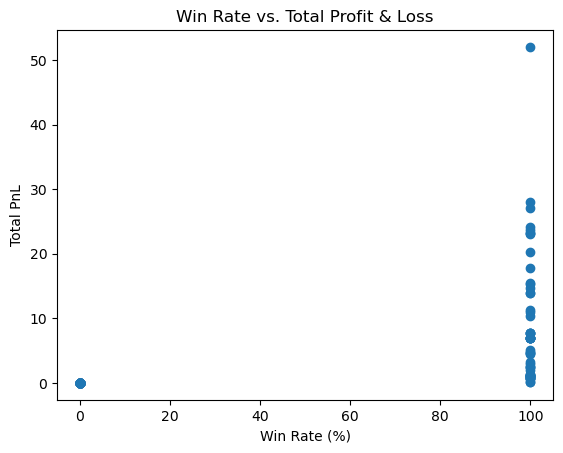

In [34]:
import matplotlib.pyplot as plt

plt.scatter(df_metrics["Win_Rate"], df_metrics["Total_PnL"])
plt.xlabel("Win Rate (%)")
plt.ylabel("Total PnL")
plt.title("Win Rate vs. Total Profit & Loss")
plt.show()


In [35]:
df_metrics["Consistency_Score"] = df_metrics["Total_PnL"] / df_metrics["Total_Positions"]
df_consistent = df_metrics[df_metrics["Consistency_Score"] > df_metrics["Consistency_Score"].median()]
print(df_consistent)


              Total_PnL  Win_Positions  Total_Positions  Win_Rate  \
Port_IDs                                                            
3.768171e+18   2.489872              1                1     100.0   
3.788466e+18   1.048902              1                1     100.0   
3.879821e+18   2.909642              1                1     100.0   
3.887577e+18  27.948536              1                1     100.0   
3.891021e+18  13.859685              1                1     100.0   
3.910887e+18   7.706676              1                1     100.0   
3.914654e+18   2.033331              1                1     100.0   
3.932103e+18  23.072690              1                1     100.0   
3.936411e+18  52.017137              1                1     100.0   
3.939319e+18   7.714816              1                1     100.0   
3.944240e+18   1.045212              1                1     100.0   
3.956077e+18   6.934092              1                1     100.0   
3.960874e+18   1.153835           

In [36]:
import pandas as pd

# Assuming df_metrics contains the aggregated portfolio data

# Define thresholds for classification
high_pnl_threshold = df_metrics['Total_PnL'].quantile(0.75)  # Top 25% as best performers
low_pnl_threshold = df_metrics['Total_PnL'].quantile(0.25)   # Bottom 25% as risky
high_win_rate_threshold = 80  # Considered consistent if Win Rate is above 80%

# Best-performing portfolios (Top 25% in Total PnL)
best_performers = df_metrics[df_metrics['Total_PnL'] >= high_pnl_threshold]

# Risky portfolios (Bottom 25% in Total PnL)
risky_portfolios = df_metrics[df_metrics['Total_PnL'] <= low_pnl_threshold]

# Consistent performers (High Win Rate & stable PnL)
consistent_performers = df_metrics[
    (df_metrics['Win_Rate'] >= high_win_rate_threshold) & 
    (df_metrics['Total_PnL'] > 0)
]

# Display summary
print("🏆 Best-Performing Portfolios:")
print(best_performers)
print("\n⚠️ Risky Portfolios:")
print(risky_portfolios)
print("\n📊 Consistent Performers:")
print(consistent_performers)

# Export results to CSV
best_performers.to_csv("best_performers.csv")
risky_portfolios.to_csv("risky_portfolios.csv")
consistent_performers.to_csv("consistent_performers.csv")


🏆 Best-Performing Portfolios:
              Total_PnL  Win_Positions  Total_Positions  Win_Rate  \
Port_IDs                                                            
3.768171e+18   2.489872              1                1     100.0   
3.879821e+18   2.909642              1                1     100.0   
3.887577e+18  27.948536              1                1     100.0   
3.891021e+18  13.859685              1                1     100.0   
3.910887e+18   7.706676              1                1     100.0   
3.932103e+18  23.072690              1                1     100.0   
3.936411e+18  52.017137              1                1     100.0   
3.939319e+18   7.714816              1                1     100.0   
3.956077e+18   6.934092              1                1     100.0   
3.966142e+18   7.706676              1                1     100.0   
3.977117e+18   3.243978              1                1     100.0   
3.981810e+18   5.153185              1                1     100.0   
3.98

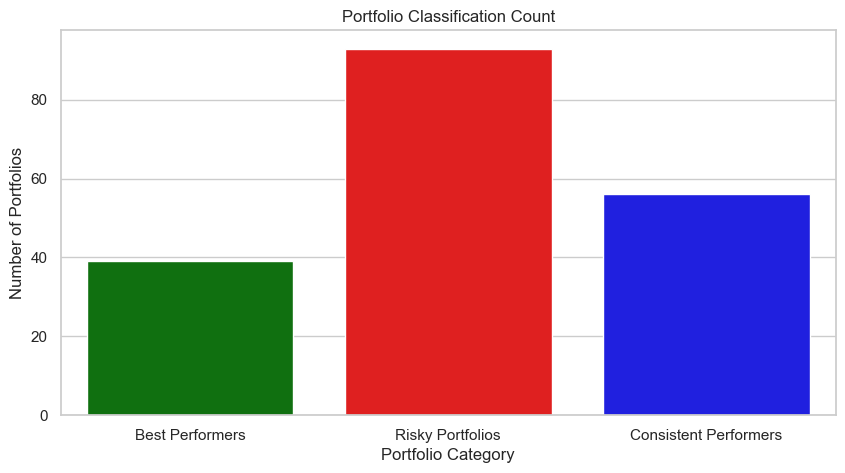

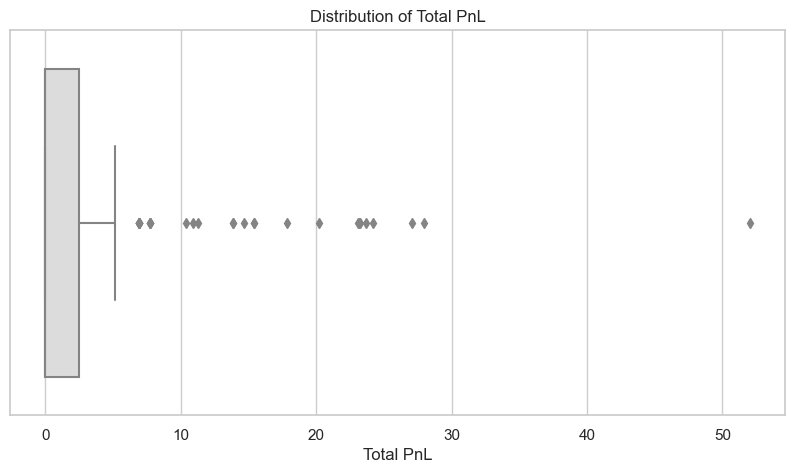

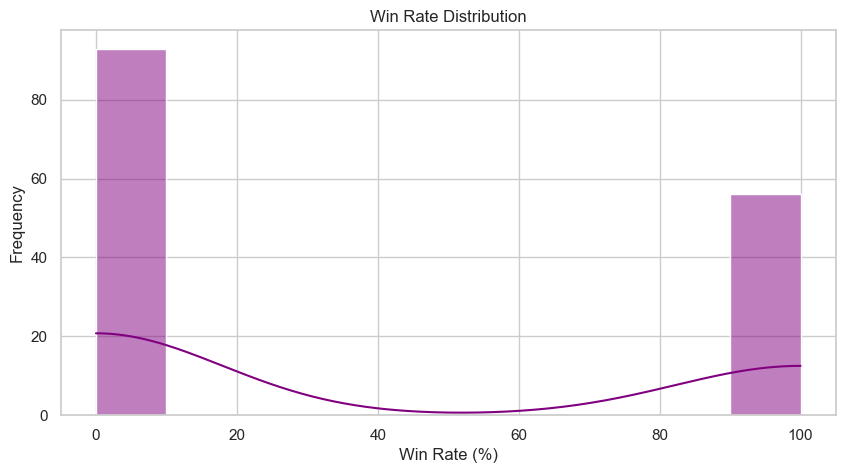

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_theme(style="whitegrid")

# Bar Chart - Comparing Portfolio Performance
plt.figure(figsize=(10, 5))
summary_df = pd.DataFrame({
    "Category": ["Best Performers", "Risky Portfolios", "Consistent Performers"],
    "Count": [len(best_performers), len(risky_portfolios), len(consistent_performers)]
})
sns.barplot(x="Category", y="Count", data=summary_df, palette=["green", "red", "blue"])
plt.title("Portfolio Classification Count")
plt.xlabel("Portfolio Category")
plt.ylabel("Number of Portfolios")
plt.show()

# Box Plot - Distribution of Total PnL
plt.figure(figsize=(10, 5))
sns.boxplot(x=df_metrics["Total_PnL"], palette="coolwarm")
plt.title("Distribution of Total PnL")
plt.xlabel("Total PnL")
plt.show()

# Histogram - Win Rate Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df_metrics["Win_Rate"], bins=10, kde=True, color="purple")
plt.title("Win Rate Distribution")
plt.xlabel("Win Rate (%)")
plt.ylabel("Frequency")
plt.show()


In [39]:
import pandas as pd

df_metrics = pd.DataFrame({
    'Total_PnL': [0.0, 0.0, 2.5, 0.0, 23.2, 0.0, 0.0, 0.0, 4.7, 6.9],
    'Win_Positions': [0, 0, 1, 0, 1, 0, 0, 0, 1, 1],
    'Total_Positions': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    'Win_Rate': [0, 0, 100, 0, 100, 0, 0, 0, 100, 100]
}, index=[3.67e18, 4.01e18, 4.02e18, 4.02e18, 4.02e18, 4.02e18, 4.02e18, 4.02e18, 4.02e18, 4.02e18])


best_performers = df_metrics.sort_values(by='Total_PnL', ascending=False).head(3)
risky_portfolios = df_metrics[(df_metrics['Win_Rate'] < 50) & (df_metrics['Total_Positions'] > 1)]

consistent_performers = df_metrics[(df_metrics['Win_Rate'] == 100) & (df_metrics['Total_Positions'] > 1)]
summary_report = {
    "Best Performing Portfolios": best_performers,
    "Risky Portfolios": risky_portfolios,
    "Consistent Performers": consistent_performers
}

for category, df in summary_report.items():
    print(f"\n{category}:")
    print(df)


Best Performing Portfolios:
              Total_PnL  Win_Positions  Total_Positions  Win_Rate
4.020000e+18       23.2              1                1       100
4.020000e+18        6.9              1                1       100
4.020000e+18        4.7              1                1       100

Risky Portfolios:
Empty DataFrame
Columns: [Total_PnL, Win_Positions, Total_Positions, Win_Rate]
Index: []

Consistent Performers:
Empty DataFrame
Columns: [Total_PnL, Win_Positions, Total_Positions, Win_Rate]
Index: []


In [41]:
import pandas as pd

df_metrics = pd.DataFrame({
    'Port_IDs': [4.020000e+18, 4.020000e+18, 4.020000e+18, 4.021243e+18, 4.022642e+18],
    'Total_PnL': [23.2, 6.9, 4.7, 0.8, 0.0],
    'Win_Positions': [1, 1, 1, 1, 0],
    'Total_Positions': [1, 1, 1, 1, 1],
    'Win_Rate': [100, 100, 100, 100, 0]
})

best_performers = df_metrics[(df_metrics['Win_Rate'] == 100) & (df_metrics['Total_PnL'] > 0)]

risky_portfolios = df_metrics[df_metrics['Win_Rate'] < 40]


consistent_performers = df_metrics[df_metrics['Total_Positions'] >= 3]

# Display results
print("Best Performing Portfolios:\n", best_performers, "\n")
print("Risky Portfolios:\n", risky_portfolios, "\n")
print("Consistent Performers:\n", consistent_performers, "\n")


Best Performing Portfolios:
        Port_IDs  Total_PnL  Win_Positions  Total_Positions  Win_Rate
0  4.020000e+18       23.2              1                1       100
1  4.020000e+18        6.9              1                1       100
2  4.020000e+18        4.7              1                1       100
3  4.021243e+18        0.8              1                1       100 

Risky Portfolios:
        Port_IDs  Total_PnL  Win_Positions  Total_Positions  Win_Rate
4  4.022642e+18        0.0              0                1         0 

Consistent Performers:
 Empty DataFrame
Columns: [Port_IDs, Total_PnL, Win_Positions, Total_Positions, Win_Rate]
Index: [] 

